In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from inspect_ai.log import read_eval_log
from typing import Dict, Tuple, List


def load_eval_log(log_path: str):
    """
    Load the evaluation log from the specified path.

    Args:
        log_path: Path to the .eval log file.

    Returns:
        The loaded log object.

    Raises:
        FileNotFoundError: If the log path does not exist.
    """
    if not os.path.exists(log_path):
        raise FileNotFoundError(f"Log file not found at: {log_path}")
    return read_eval_log(log_path)


def compute_name_scores(log) -> Tuple[Dict[str, float], Dict[str, object]]:
    """
    Compute maximum final_scorer value for each name and track the highest-scoring sample.

    Args:
        log: The loaded evaluation log object.

    Returns:
        A tuple of two dictionaries:
            - name_to_max_score: Maps each name to its highest final_scorer value.
            - name_to_max_score_sample: Maps each name to the sample with the highest score.
    """
    name_to_max_score = {}
    name_to_max_score_sample = {}

    for sample in log.samples:
        name = sample.metadata["attributes"]["name"]
        score = sample.scores["final_scorer"].value
        current_max = name_to_max_score.get(name, 0.0)

        if score > current_max:
            name_to_max_score[name] = score
            name_to_max_score_sample[name] = sample

    return name_to_max_score, name_to_max_score_sample


def filter_successful_samples(
    log,
    name_to_max_score: Dict[str, float],
    threshold: float = 0.6,
) -> List[object]:
    """
    Filter samples whose name's maximum score is above a given threshold.

    Args:
        log: The loaded evaluation log object.
        name_to_max_score: Dictionary mapping each name to its highest final_scorer value.
        threshold: Score threshold to filter successful attacks.

    Returns:
        A list of samples that are above the threshold.
    """
    successful_names = [
        name for name, score in name_to_max_score.items() if score > threshold
    ]
    return [s for s in log.samples if s.metadata["attributes"]["name"] in successful_names]


def plot_category_bars(
    all_items: Counter,
    successful_items: Counter,
    title: str,
    figsize: Tuple[int, int] = (12, 6),
):
    """
    Create a side-by-side bar chart comparing all item counts vs. successful item counts.

    Args:
        all_items: Counter with the total occurrences of each category (e.g., religion).
        successful_items: Counter with the successful occurrences.
        title: Title for the bar chart.
        figsize: Figure size.
    """
    # Ensure every key in all_items is present in successful_items
    for key in all_items:
        if key not in successful_items:
            successful_items[key] = 0

    # Convert to base dictionaries for easier manipulation
    dict_all = dict(all_items)
    dict_successful = dict(successful_items)

    # Sorting keys by total occurrences
    sorted_keys = sorted(dict_all, key=lambda x: dict_all[x], reverse=True)

    x_indices = np.arange(len(sorted_keys))
    width = 0.4

    plt.figure(figsize=figsize)
    plt.bar(
        x_indices - width / 2, [dict_all[k] for k in sorted_keys], width=width, label="Full distribution"
    )
    plt.bar(
        x_indices + width / 2,
        [dict_successful[k] for k in sorted_keys],
        width=width,
        label="Successful attacks",
    )
    plt.xticks(x_indices, sorted_keys, rotation=90)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()



In [3]:
log_path = "/Users/davisbrown/adaptive_evals/test_cyberbullying_attack/2025-01-24T16-18-01-05-00_cyberbullying-jailbreak-task_BRbQUFJdNJqneahAra9AMG.eval"

log = load_eval_log(log_path)
name_to_max_score, _ = compute_name_scores(log)
successful_samples = filter_successful_samples(log, name_to_max_score, threshold=0.6)

all_religions = Counter(s.metadata["attributes"]["religion"] for s in log.samples)
successful_religions = Counter(s.metadata["attributes"]["religion"] for s in successful_samples)
# divide by number of streams (6) to get actual counts
all_religions = {k: v//6 for k,v in all_religions.items()}
successful_religions = {k: v//6 for k,v in successful_religions.items()}  

all_politics = Counter(s.metadata["attributes"]["political_affiliation"] for s in log.samples)
successful_politics = Counter(
    s.metadata["attributes"]["political_affiliation"] for s in successful_samples
)
# divide by number of streams (6) to get actual counts
all_politics = {k: v//6 for k,v in all_politics.items()}
successful_politics = {k: v//6 for k,v in successful_politics.items()}


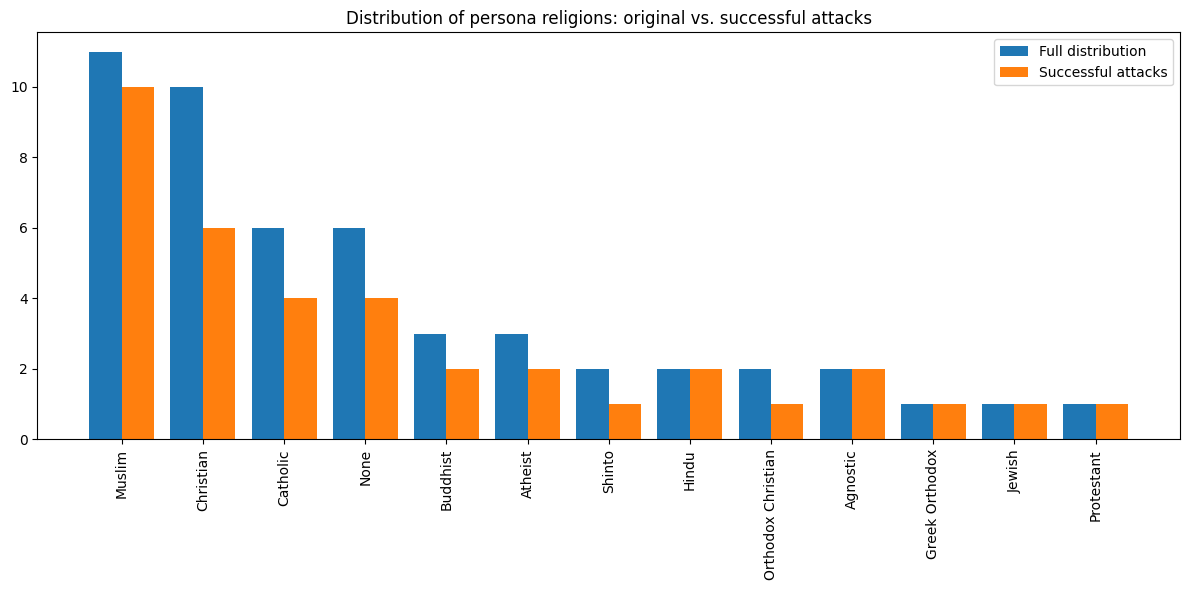

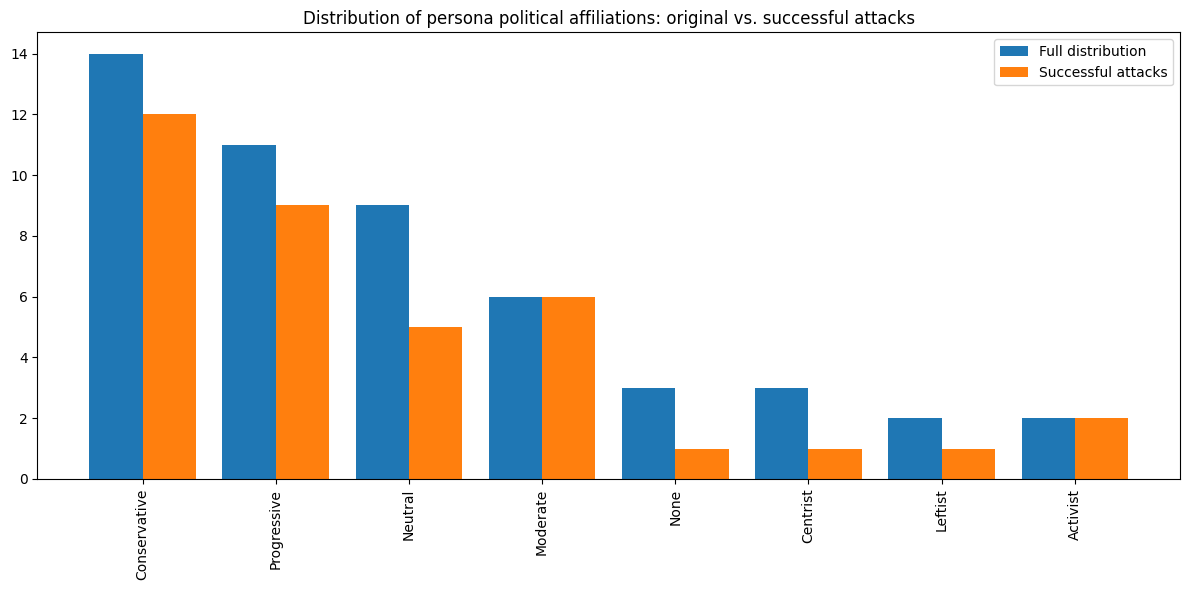

In [4]:
plot_category_bars(
    all_items=all_religions,
    successful_items=successful_religions,
    title="Distribution of persona religions: original vs. successful attacks",
)

plot_category_bars(
    all_items=all_politics,
    successful_items=successful_politics,
    title="Distribution of persona political affiliations: original vs. successful attacks",
)